In [2]:
import sys
sys.path.append('/Users/chanagan/Documents/GitHub/ImageryResources/Functions/')
import TiffTools as tt

# reload modules when changed
%reload_ext autoreload
%autoreload 2

from pyproj import Proj, Geod
import rasterio
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

crs = 'epsg:32610'

P = Proj(crs)
G = Geod(ellps='WGS84')

In [8]:
# Parkfield lat/lon → convert to your CRS
Px, Py = P(-120.441, 35.899)

# RTK AA
f = '/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/AA_StationCompilations/AlignmentArrayVelocities_SingleLTandST_NEW.csv'
aartk = pd.read_csv(f,comment='#')
aartk[aartk['Name'] != 'Topo Creek']
aartk.replace(-9999, np.nan, inplace=True)
aartk['easting'] = P(aartk['Longitude'].values,aartk['Latitude'].values)[0]
aartk['northing'] = P(aartk['Longitude'].values,aartk['Latitude'].values)[1]
aartk["dist_from_parkfield_m"] = np.sqrt(
    (aartk.easting - Px)**2 +
    (aartk.northing - Py)**2
)


lidERFdf = pd.read_csv('/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/AA_StationCompilations/LidarAtAlignmentArrayERF_ALL_PAIRS_NEW.csv')
lidERFdf = lidERFdf[lidERFdf['Name'] != 'Topo Creek']
lidERFdf["dist_from_parkfield_m"] = np.sqrt(
    (lidERFdf['Easting (m)'] - Px)**2 +
    (lidERFdf['Northing (m)'] - Py)**2
)

#gnss = pd.read_csv('https://geodesy.unr.edu/gps_timeseries/IGS20/midas/midas.NA.txt',skiprows=35,sep='\s+')
#columns = ['ID','ver','first_epoch','last_epoch','duration','nepochs','nepochsgood','npairs','dE','dN','dU','dEsig','dNsig','dUsig','offsetE','offsetN','offsetU','dEout','dNout','dUout','dEstd_pairs','dNstd_pairs','dUstd_pairs','nSteps','latitude','longitude','height']
#gnss.columns = columns
#gnss['easting'] = P(gnss['longitude'].values,gnss['latitude'].values)[0]
#gnss['northing'] = P(gnss['longitude'].values,gnss['latitude'].values)[1]
#gnss = gnss[(gnss.easting < aartk.easting.max())&
#            (gnss.easting > aartk.easting.min())&
#            (gnss.northing < aartk.northing.max())&
#            (gnss.northing > aartk.northing.min())]
#gnss["dist_from_parkfield_m"] = np.sqrt(
#    (gnss.easting - Px)**2 +
#    (gnss.northing - Py)**2
#)

sarE = rasterio.open('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/Xu_et_al_2021_vel_decomp/East_defo_cm_yr_epsg32610.tif',masked=True)
sarN = rasterio.open('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/Xu_et_al_2021_vel_decomp/North_defo_cm_yr_epsg32610.tif',masked=True)
sarU = rasterio.open('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/Xu_et_al_2021_vel_decomp/Up_defo_cm_yr_epsg32610.tif',masked=True)
lidE = rasterio.open('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/MicmacAreaResults/SsResolOpt1/MaskedResults/Velocities/EW_velocity_merged.tif',masked=True)
lidN = rasterio.open('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/MicmacAreaResults/SsResolOpt1/MaskedResults/Velocities/NS_velocity_merged.tif',masked=True)

faults = gpd.read_file(
    "/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/GIS/cSAF_fault_mapping_USGS.geojson"
)
faults = faults.to_crs("EPSG:32610")

In [4]:
# Define center points for AA Transects
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

aas = np.unique(aartk['Name'])
aas = aas[aas != 'Topo Creek']

center_points = gpd.GeoDataFrame({
    'geometry': [None]*len(aas),
    'fault_azimuth': np.zeros(len(aas)),
    'Name': aas
}, crs=crs)

for i, naa in enumerate(aas):
    subset = aartk[aartk['Name'] == naa]
    
    x_mean = subset['easting'].mean()
    y_mean = subset['northing'].mean()
    
    center_points.loc[i, 'geometry'] = Point(x_mean, y_mean)
    center_points.loc[i, 'fault_azimuth'] = subset['Fault Azimuth'].mean()


In [5]:
# Titus Digitized Geologic Transects
flist1 = ['/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/TitusPointsDigitized/FaultPerpendicularNWCreepingFigure10B.csv',
          '/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/TitusPointsDigitized/FaultParallelNWCreepingFigure10A.csv']
flist2 = ['/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/TitusPointsDigitized/FaultParallelCentralCreepingFigure10C.csv',
'/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/TitusPointsDigitized/FaultPerpendicularCentralCreepingFigure10D.csv']


# NW Bitterwater transect: 73,100 m from parkfield, closest to Smith Ranch
## endpoints 633460,3987642 and 713165,4056462 assuming transect angle -42 degrees

# Central Slack Canyon transect: 30,000 m from parkfield, closest to Peachtree, compare to slack though
## length 105,500 m approx for both
for f, name in zip([flist1[0],flist1[1],flist2[0],flist2[1]],['Smith Ranch','Smith Ranch','Peachtree Valley','Peachtree Valley']):
    tdf = pd.read_csv(f,header=None,names=['dist','rate'])
    center_x, center_y = center_points[center_points['Name'] == name].geometry.x, center_points[center_points['Name'] == name].geometry.y
    centerLon, centerLat = P(center_x, center_y,inverse=True)
    lon = np.full(len(tdf), float(centerLon[0]))
    lat = np.full(len(tdf), float(centerLat[0]))
    az  = np.full(len(tdf), -42.0)
    dist = np.asarray(tdf['dist'], dtype=float).ravel()
    lon2, lat2, backaz = G.fwd(lon, lat, az, dist)
    tdf['easting'], tdf['northing'] = P(lon2, lat2)
    if name == 'Smith Ranch':
        tdf['dist_from_parkfield_m'] = 73100
    else:
        tdf['dist_from_parkfield_m'] = 30000
    #tdf.to_csv(f'{f[:-4]}refed.csv',index=False)

# Manually manipulated to 
titdf = pd.read_csv('/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/TitusPointsDigitized/TitusDigitizedGeologicCreepRatesFigure10.csv')
titdf = titdf.replace(-9999,np.nan)

## Decomposed SAR

Xu et al., 2021

In [6]:
gdal_edit.py \
 -a_nodata -9999\
  /Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/Xu_et_al_2021_vel_decomp/Up_defo_cm_yr_epsg32610.tif

gdalwarp -t_srs EPSG:32610 -te 630402.1 3964524.5 741690.6 4078192.7 -srcband 1 -dstband 1 -srcnodata 128 -dstnodata -9999 -ot Float32 -overwrite -of GTiff -co COMPRESS=LZW -co ZLEVEL=9 -co BIGTIFF=YES \
    /Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/Xu_et_al_2021_vel_decomp/Up_defo_cm_yr.tif \
    /Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/Xu_et_al_2021_vel_decomp/Up_defo_cm_yr_epsg32610.tif

SyntaxError: invalid syntax (2912516599.py, line 5)

In [ ]:
gdalwarp -t_srs EPSG:32610 -te 630402.1 3964524.5 741690.6 4078192.7 -srcnodata -9999 -dstnodata -9999 -overwrite -of GTiff -co COMPRESS=LZW -co ZLEVEL=9 -co BIGTIFF=YES \
    /Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/Xu_et_al_2021_vel_decomp/North_defo_cm_yr.tif \
    /Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/Xu_et_al_2021_vel_decomp/North_defo_cm_yr_epsg32610.tif

SyntaxError: invalid syntax (3537640285.py, line 1)

In [ ]:
profile_length, profile_width, pixel_res = 40000, 2000, 200
lid_profile_length, lid_profile_width, lid_pixel_res = 1000, 10, 0.5
fname = '/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/AA_StationCompilations/InSARAtAlignmentArrayERF_ALL_PAIRS_NEW.csv'

Bounds: Intercept, offset, fault location, 1/4 shear width, slope1, slope2
 ((-inf, np.float64(-2.6112533350104834), np.float64(-19900.0), 0, np.float64(-6.560938027664531e-06), np.float64(-6.560938027664531e-06)), (inf, np.float64(2.6112533350104834), np.float64(19900.0), 5000, np.float64(6.560938027664531e-06), np.float64(6.560938027664531e-06)))
Returning intercept, offset at fault location, shifted fault location, 1/2 1 std shear width (4 shear width is 2 sigma 
               fault zone width), uncertainties for those parameters, then lhs slope and uncertainty, and rhs slope and uncertainty). 
               Other derived parameters are the offset at the edges of the 2 sigma shear zone, the max offset, and the endpoint offset.
               The latter two are from left to right across profile.
Returning intercept, offset at fault location, shifted fault location, 1/2 1 std shear width (4 shear width is 2 sigma 
               fault zone width), uncertainties for those parameters,

/var/folders/cl/y9nzvjr51wjdfxvfj59yzn400000gp/T/ipykernel_37406/972842270.py:89: RuntimeWarning: Mean of empty slice
  df['Short-term North Velocity (cm/yr)'].values - np.nanmean(df['Short-term North Velocity (cm/yr)']),
/var/folders/cl/y9nzvjr51wjdfxvfj59yzn400000gp/T/ipykernel_37406/972842270.py:90: RuntimeWarning: Mean of empty slice
  df['Short-term East Velocity (cm/yr)'].values - np.nanmean(df['Short-term East Velocity (cm/yr)']),
/Users/chanagan/Documents/GitHub/ImageryResources/Functions/TiffTools.py:1013: RuntimeWarning: All-NaN slice encountered
  samps_mean = (np.nanmax(samps)+np.nanmin(samps))/2
/Users/chanagan/Documents/GitHub/ImageryResources/Functions/TiffTools.py:1018: RuntimeWarning: All-NaN slice encountered
  max_diff = np.nanmax(samps)-np.nanmin(samps)


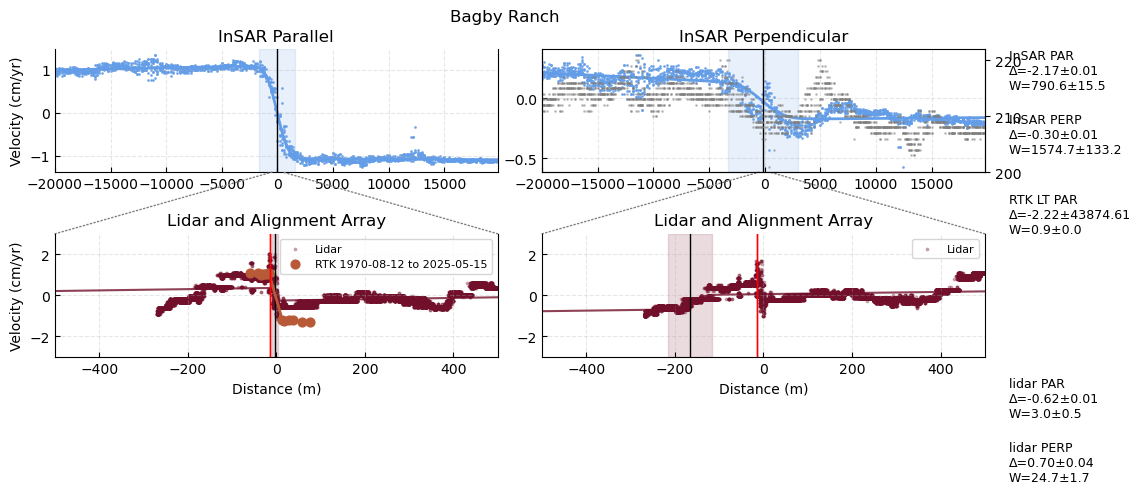

Saving profile fits to: /Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/AA_StationCompilations/InSARAtAlignmentArrayERF_ALL_PAIRS_NEW.csv
Bounds: Intercept, offset, fault location, 1/4 shear width, slope1, slope2
 ((-inf, np.float64(-3.1601216081234904), np.float64(-19900.0), 0, np.float64(-7.940004040511283e-06), np.float64(-7.940004040511283e-06)), (inf, np.float64(3.1601216081234904), np.float64(19900.0), 5000, np.float64(7.940004040511283e-06), np.float64(7.940004040511283e-06)))
Returning intercept, offset at fault location, shifted fault location, 1/2 1 std shear width (4 shear width is 2 sigma 
               fault zone width), uncertainties for those parameters, then lhs slope and uncertainty, and rhs slope and uncertainty). 
               Other derived parameters are the offset at the edges of the 2 sigma shear zone, the max offset, and the endpoint offset.
               The latter two are from left to right across profile.
Returning intercept, off

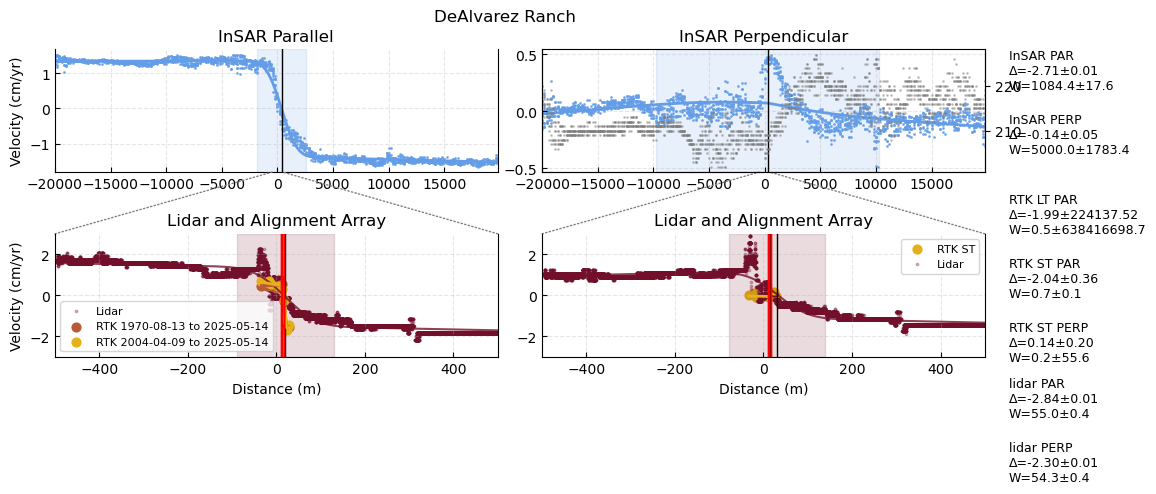

Saving profile fits to: /Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/AA_StationCompilations/InSARAtAlignmentArrayERF_ALL_PAIRS_NEW.csv
Bounds: Intercept, offset, fault location, 1/4 shear width, slope1, slope2
 ((-inf, np.float64(-2.1538884018278965), np.float64(-19900.0), 0, np.float64(-5.4117799040901924e-06), np.float64(-5.4117799040901924e-06)), (inf, np.float64(2.1538884018278965), np.float64(19900.0), 5000, np.float64(5.4117799040901924e-06), np.float64(5.4117799040901924e-06)))
Returning intercept, offset at fault location, shifted fault location, 1/2 1 std shear width (4 shear width is 2 sigma 
               fault zone width), uncertainties for those parameters, then lhs slope and uncertainty, and rhs slope and uncertainty). 
               Other derived parameters are the offset at the edges of the 2 sigma shear zone, the max offset, and the endpoint offset.
               The latter two are from left to right across profile.
Returning intercept,

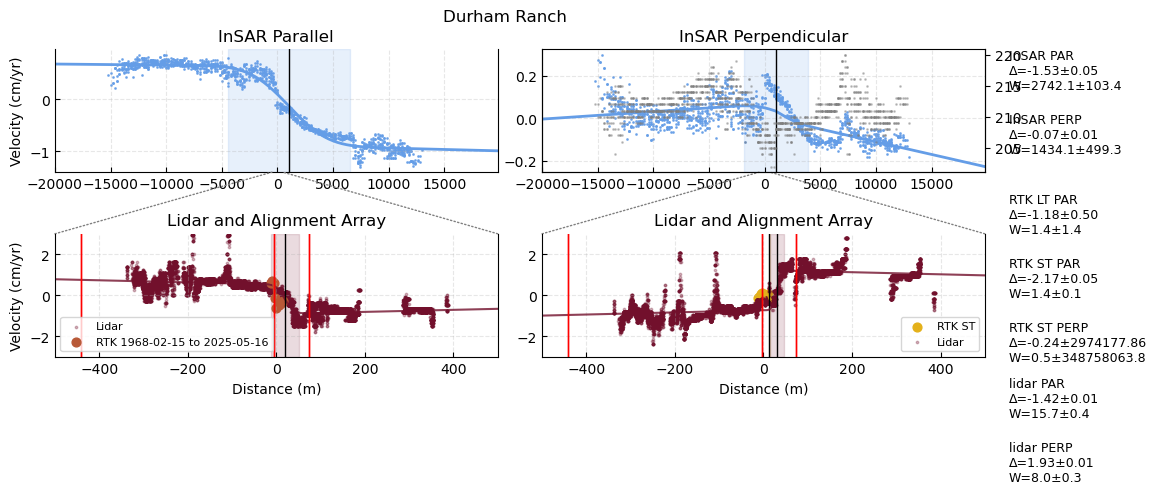

Saving profile fits to: /Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/AA_StationCompilations/InSARAtAlignmentArrayERF_ALL_PAIRS_NEW.csv
Bounds: Intercept, offset, fault location, 1/4 shear width, slope1, slope2
 ((-inf, np.float64(-3.013815605592606), np.float64(-19900.0), 0, np.float64(-7.5724010190769e-06), np.float64(-7.5724010190769e-06)), (inf, np.float64(3.013815605592606), np.float64(19900.0), 5000, np.float64(7.5724010190769e-06), np.float64(7.5724010190769e-06)))
Returning intercept, offset at fault location, shifted fault location, 1/2 1 std shear width (4 shear width is 2 sigma 
               fault zone width), uncertainties for those parameters, then lhs slope and uncertainty, and rhs slope and uncertainty). 
               Other derived parameters are the offset at the edges of the 2 sigma shear zone, the max offset, and the endpoint offset.
               The latter two are from left to right across profile.
Returning intercept, offset at fau

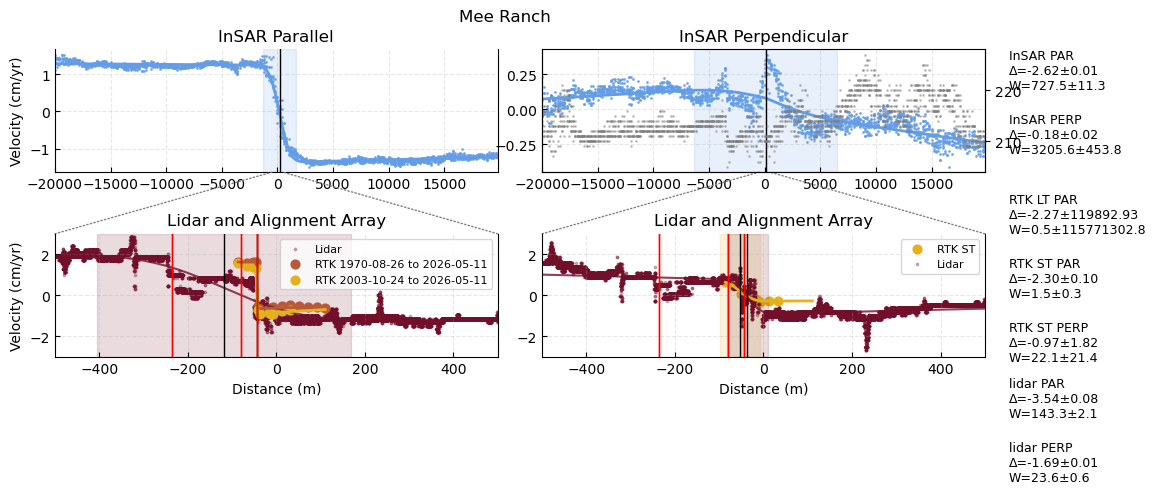

Saving profile fits to: /Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/AA_StationCompilations/InSARAtAlignmentArrayERF_ALL_PAIRS_NEW.csv
Bounds: Intercept, offset, fault location, 1/4 shear width, slope1, slope2
 ((-inf, np.float64(-3.111238006176267), np.float64(-19900.0), 0, np.float64(-7.81718092004087e-06), np.float64(-7.81718092004087e-06)), (inf, np.float64(3.111238006176267), np.float64(19900.0), 5000, np.float64(7.81718092004087e-06), np.float64(7.81718092004087e-06)))
Returning intercept, offset at fault location, shifted fault location, 1/2 1 std shear width (4 shear width is 2 sigma 
               fault zone width), uncertainties for those parameters, then lhs slope and uncertainty, and rhs slope and uncertainty). 
               Other derived parameters are the offset at the edges of the 2 sigma shear zone, the max offset, and the endpoint offset.
               The latter two are from left to right across profile.
Returning intercept, offset at

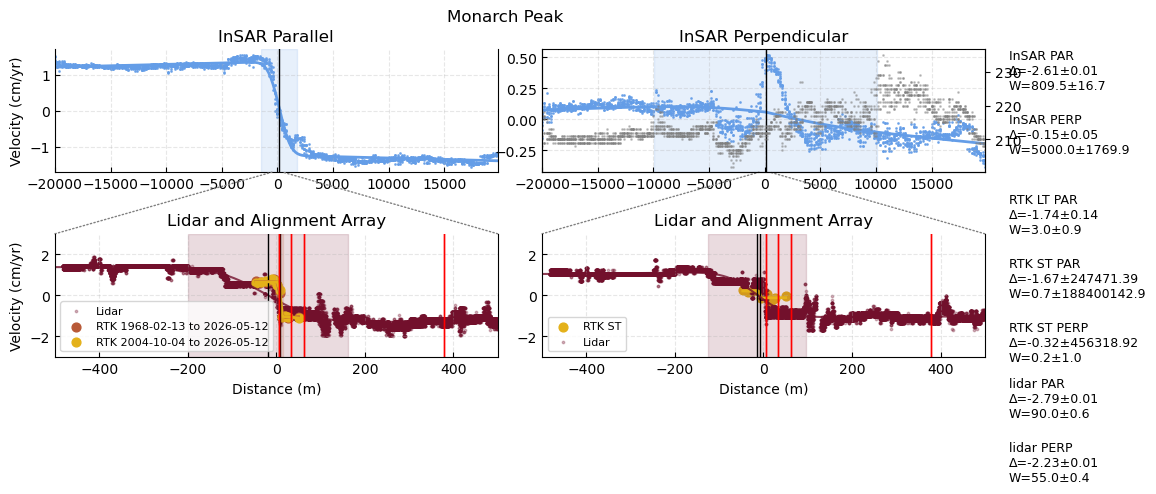

Saving profile fits to: /Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/AA_StationCompilations/InSARAtAlignmentArrayERF_ALL_PAIRS_NEW.csv
Bounds: Intercept, offset, fault location, 1/4 shear width, slope1, slope2
 ((-inf, np.float64(-3.027281799834799), np.float64(-19900.0), 0, np.float64(-7.606235677976882e-06), np.float64(-7.606235677976882e-06)), (inf, np.float64(3.027281799834799), np.float64(19900.0), 5000, np.float64(7.606235677976882e-06), np.float64(7.606235677976882e-06)))
Returning intercept, offset at fault location, shifted fault location, 1/2 1 std shear width (4 shear width is 2 sigma 
               fault zone width), uncertainties for those parameters, then lhs slope and uncertainty, and rhs slope and uncertainty). 
               Other derived parameters are the offset at the edges of the 2 sigma shear zone, the max offset, and the endpoint offset.
               The latter two are from left to right across profile.
Returning intercept, offse

/var/folders/cl/y9nzvjr51wjdfxvfj59yzn400000gp/T/ipykernel_37406/972842270.py:89: RuntimeWarning: Mean of empty slice
  df['Short-term North Velocity (cm/yr)'].values - np.nanmean(df['Short-term North Velocity (cm/yr)']),
/var/folders/cl/y9nzvjr51wjdfxvfj59yzn400000gp/T/ipykernel_37406/972842270.py:90: RuntimeWarning: Mean of empty slice
  df['Short-term East Velocity (cm/yr)'].values - np.nanmean(df['Short-term East Velocity (cm/yr)']),
/Users/chanagan/Documents/GitHub/ImageryResources/Functions/TiffTools.py:1013: RuntimeWarning: All-NaN slice encountered
  samps_mean = (np.nanmax(samps)+np.nanmin(samps))/2
/Users/chanagan/Documents/GitHub/ImageryResources/Functions/TiffTools.py:1018: RuntimeWarning: All-NaN slice encountered
  max_diff = np.nanmax(samps)-np.nanmin(samps)


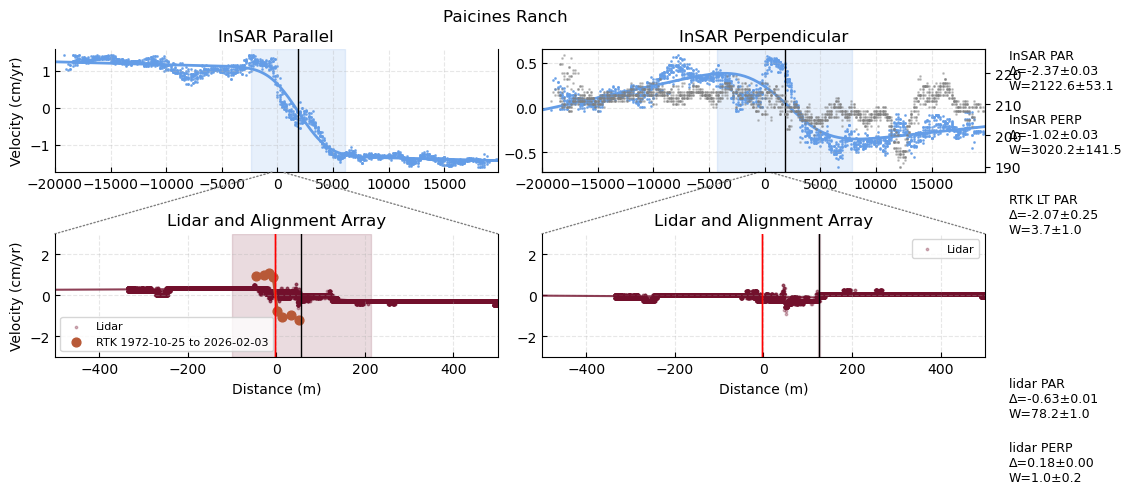

Saving profile fits to: /Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/AA_StationCompilations/InSARAtAlignmentArrayERF_ALL_PAIRS_NEW.csv
Bounds: Intercept, offset, fault location, 1/4 shear width, slope1, slope2
 ((-inf, np.float64(-3.0236324566337442), np.float64(-19900.0), 0, np.float64(-7.597066473954132e-06), np.float64(-7.597066473954132e-06)), (inf, np.float64(3.0236324566337442), np.float64(19900.0), 5000, np.float64(7.597066473954132e-06), np.float64(7.597066473954132e-06)))
Returning intercept, offset at fault location, shifted fault location, 1/2 1 std shear width (4 shear width is 2 sigma 
               fault zone width), uncertainties for those parameters, then lhs slope and uncertainty, and rhs slope and uncertainty). 
               Other derived parameters are the offset at the edges of the 2 sigma shear zone, the max offset, and the endpoint offset.
               The latter two are from left to right across profile.
Returning intercept, off

/var/folders/cl/y9nzvjr51wjdfxvfj59yzn400000gp/T/ipykernel_37406/972842270.py:89: RuntimeWarning: Mean of empty slice
  df['Short-term North Velocity (cm/yr)'].values - np.nanmean(df['Short-term North Velocity (cm/yr)']),
/var/folders/cl/y9nzvjr51wjdfxvfj59yzn400000gp/T/ipykernel_37406/972842270.py:90: RuntimeWarning: Mean of empty slice
  df['Short-term East Velocity (cm/yr)'].values - np.nanmean(df['Short-term East Velocity (cm/yr)']),
/Users/chanagan/Documents/GitHub/ImageryResources/Functions/TiffTools.py:1013: RuntimeWarning: All-NaN slice encountered
  samps_mean = (np.nanmax(samps)+np.nanmin(samps))/2
/Users/chanagan/Documents/GitHub/ImageryResources/Functions/TiffTools.py:1018: RuntimeWarning: All-NaN slice encountered
  max_diff = np.nanmax(samps)-np.nanmin(samps)


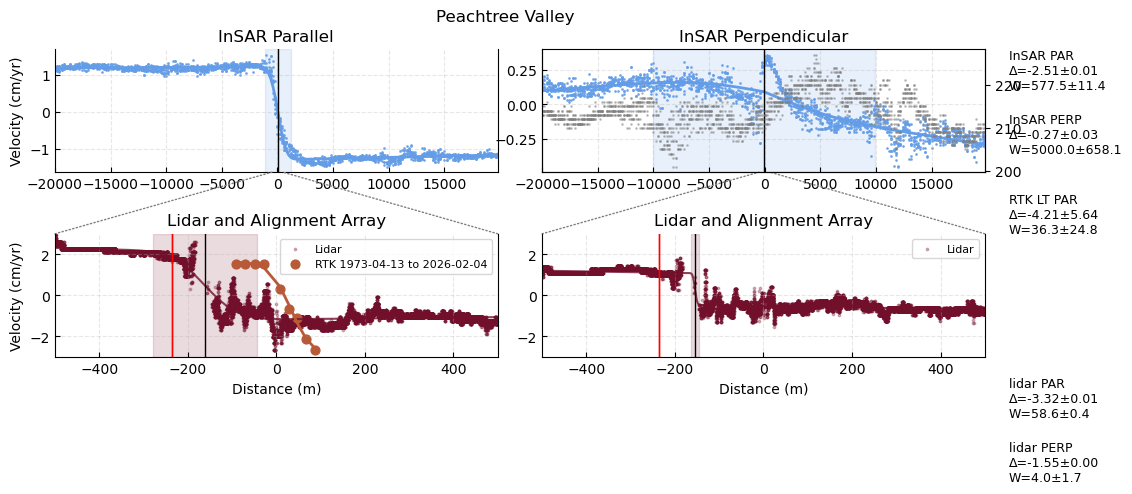

Saving profile fits to: /Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/AA_StationCompilations/InSARAtAlignmentArrayERF_ALL_PAIRS_NEW.csv
Bounds: Intercept, offset, fault location, 1/4 shear width, slope1, slope2
 ((-inf, np.float64(-3.1378253802449994), np.float64(-19900.0), 0, np.float64(-7.883983367449748e-06), np.float64(-7.883983367449748e-06)), (inf, np.float64(3.1378253802449994), np.float64(19900.0), 5000, np.float64(7.883983367449748e-06), np.float64(7.883983367449748e-06)))
Returning intercept, offset at fault location, shifted fault location, 1/2 1 std shear width (4 shear width is 2 sigma 
               fault zone width), uncertainties for those parameters, then lhs slope and uncertainty, and rhs slope and uncertainty). 
               Other derived parameters are the offset at the edges of the 2 sigma shear zone, the max offset, and the endpoint offset.
               The latter two are from left to right across profile.
Returning intercept, off

/var/folders/cl/y9nzvjr51wjdfxvfj59yzn400000gp/T/ipykernel_37406/972842270.py:89: RuntimeWarning: Mean of empty slice
  df['Short-term North Velocity (cm/yr)'].values - np.nanmean(df['Short-term North Velocity (cm/yr)']),
/var/folders/cl/y9nzvjr51wjdfxvfj59yzn400000gp/T/ipykernel_37406/972842270.py:90: RuntimeWarning: Mean of empty slice
  df['Short-term East Velocity (cm/yr)'].values - np.nanmean(df['Short-term East Velocity (cm/yr)']),
/Users/chanagan/Documents/GitHub/ImageryResources/Functions/TiffTools.py:1013: RuntimeWarning: All-NaN slice encountered
  samps_mean = (np.nanmax(samps)+np.nanmin(samps))/2
/Users/chanagan/Documents/GitHub/ImageryResources/Functions/TiffTools.py:1018: RuntimeWarning: All-NaN slice encountered
  max_diff = np.nanmax(samps)-np.nanmin(samps)


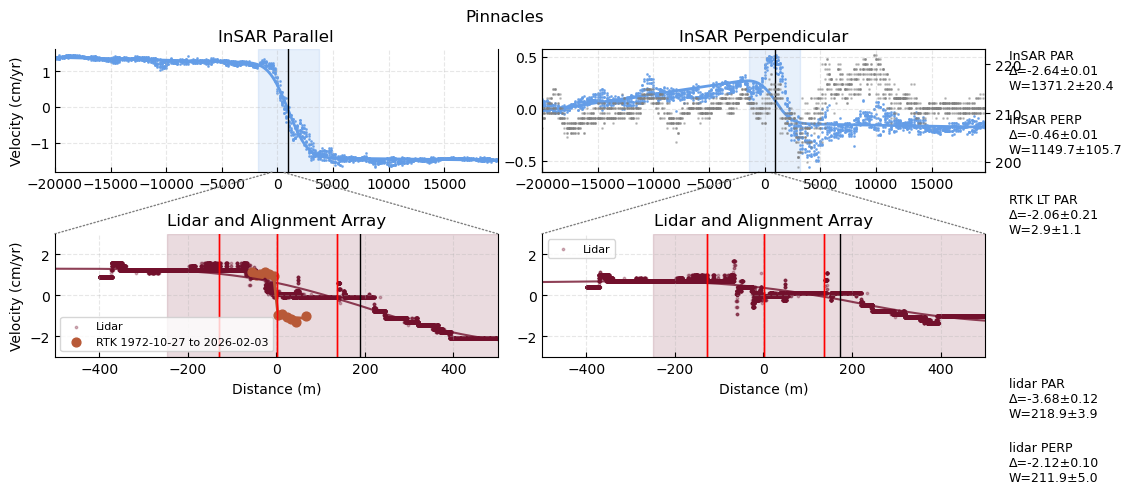

Saving profile fits to: /Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/AA_StationCompilations/InSARAtAlignmentArrayERF_ALL_PAIRS_NEW.csv
Bounds: Intercept, offset, fault location, 1/4 shear width, slope1, slope2
 ((-inf, np.float64(-2.7441416743266602), np.float64(-19900.0), 0, np.float64(-6.89482832745392e-06), np.float64(-6.89482832745392e-06)), (inf, np.float64(2.7441416743266602), np.float64(19900.0), 5000, np.float64(6.89482832745392e-06), np.float64(6.89482832745392e-06)))
Returning intercept, offset at fault location, shifted fault location, 1/2 1 std shear width (4 shear width is 2 sigma 
               fault zone width), uncertainties for those parameters, then lhs slope and uncertainty, and rhs slope and uncertainty). 
               Other derived parameters are the offset at the edges of the 2 sigma shear zone, the max offset, and the endpoint offset.
               The latter two are from left to right across profile.
Returning intercept, offset 

/Users/chanagan/Documents/GitHub/ImageryResources/Functions/TiffTools.py:1026: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(erf_function_twoslope, dists[~np.isnan(samps)], samps[~np.isnan(samps)], maxfev=1e9,ftol=1e-9,bounds=bounds,p0=p0,nan_policy='omit')


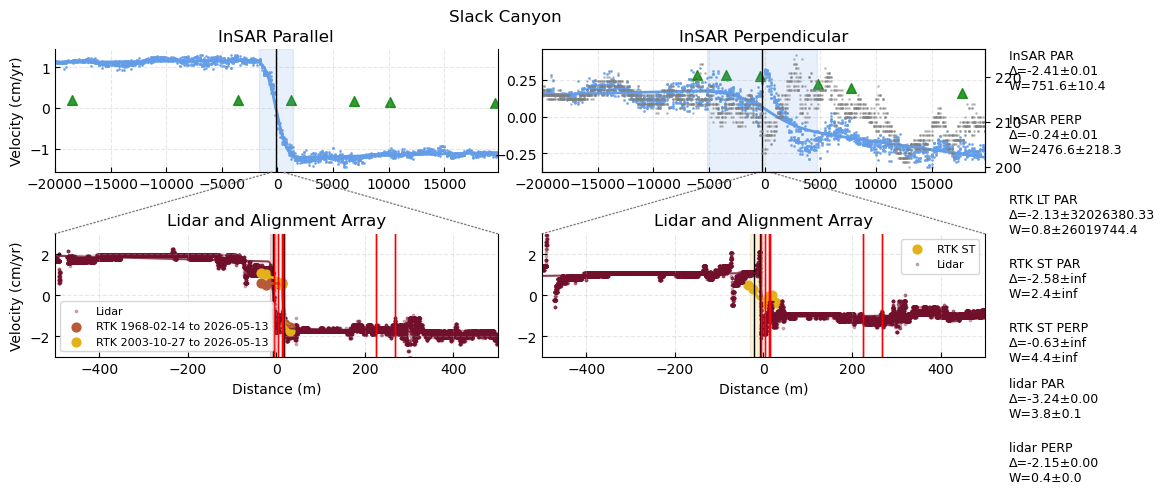

Saving profile fits to: /Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/AA_StationCompilations/InSARAtAlignmentArrayERF_ALL_PAIRS_NEW.csv
Bounds: Intercept, offset, fault location, 1/4 shear width, slope1, slope2
 ((-inf, np.float64(-3.147986956388593), np.float64(-19900.0), 0, np.float64(-7.909514965800484e-06), np.float64(-7.909514965800484e-06)), (inf, np.float64(3.147986956388593), np.float64(19900.0), 5000, np.float64(7.909514965800484e-06), np.float64(7.909514965800484e-06)))
Returning intercept, offset at fault location, shifted fault location, 1/2 1 std shear width (4 shear width is 2 sigma 
               fault zone width), uncertainties for those parameters, then lhs slope and uncertainty, and rhs slope and uncertainty). 
               Other derived parameters are the offset at the edges of the 2 sigma shear zone, the max offset, and the endpoint offset.
               The latter two are from left to right across profile.
Returning intercept, offse

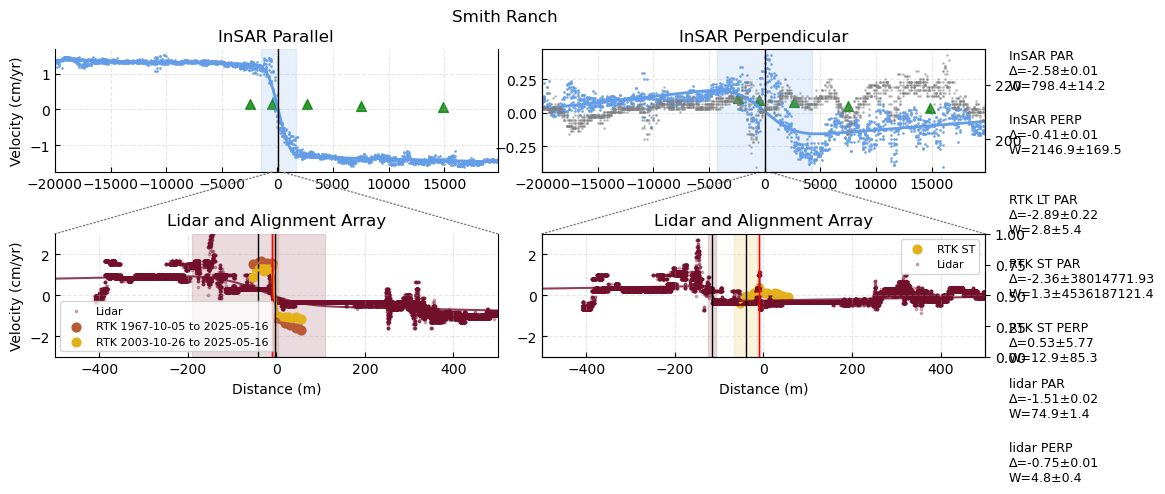

Saving profile fits to: /Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/AA_StationCompilations/InSARAtAlignmentArrayERF_ALL_PAIRS_NEW.csv
Bounds: Intercept, offset, fault location, 1/4 shear width, slope1, slope2
 ((-inf, np.float64(-3.001039385493514), np.float64(-19900.0), 0, np.float64(-7.540299963551543e-06), np.float64(-7.540299963551543e-06)), (inf, np.float64(3.001039385493514), np.float64(19900.0), 5000, np.float64(7.540299963551543e-06), np.float64(7.540299963551543e-06)))
Returning intercept, offset at fault location, shifted fault location, 1/2 1 std shear width (4 shear width is 2 sigma 
               fault zone width), uncertainties for those parameters, then lhs slope and uncertainty, and rhs slope and uncertainty). 
               Other derived parameters are the offset at the edges of the 2 sigma shear zone, the max offset, and the endpoint offset.
               The latter two are from left to right across profile.
Returning intercept, offse

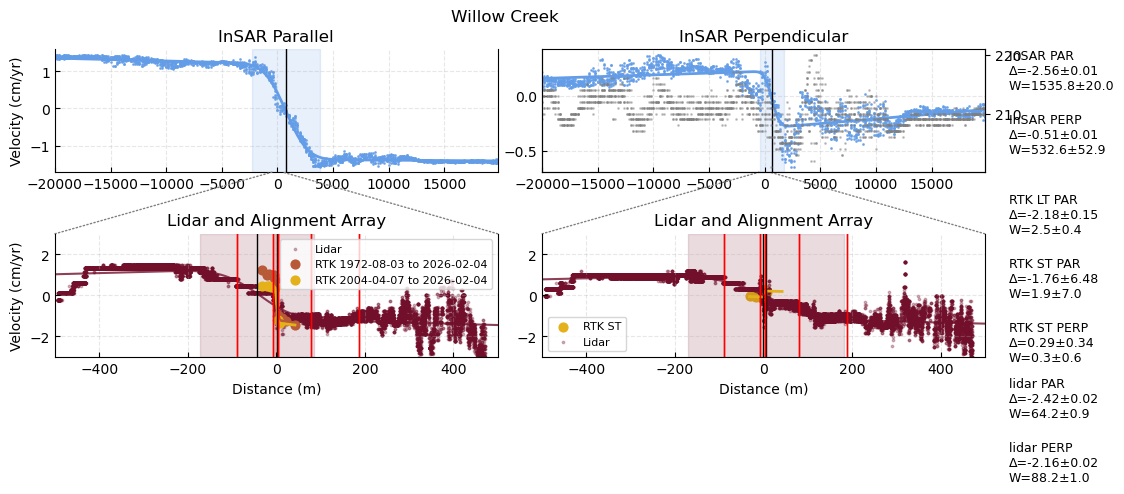

Saving profile fits to: /Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/AA_StationCompilations/InSARAtAlignmentArrayERF_ALL_PAIRS_NEW.csv


In [12]:
# loop through center points along fault 
# each profile has one defined center
from matplotlib.patches import Rectangle, ConnectionPatch
from shapely.geometry import LineString

def make_cols(prefix):
    return [
        f'{prefix} Intercept', f'{prefix} Fault Rate ',
        f'{prefix} Fault Location', f'{prefix} Shear Width',
        f'{prefix} Fault Rate Sigma', f'{prefix} Fault Location Sigma',
        f'{prefix} Shear Width Sigma', f'{prefix} Slope 1',
        f'{prefix} Slope1 Sigma', f'{prefix} Slope2',
        f'{prefix} Slope2 Sigma', f'{prefix} FZW Rate',
        f'{prefix} EP Rate', f'{prefix} Intercept Sigma'
    ]
sar_cols = ['Name','Fault Azimuth',
           'Easting (m)','Northing (m)'] \
          + make_cols('InSAR Parallel') \
          + make_cols('InSAR Perpendicular')

sarERFdf = pd.DataFrame(columns=sar_cols)

points = center_points#[((center_points['Name'] == 'Slack Canyon') | (center_points['Name'] == 'Smith Ranch'))]
points.fault_azimuth = [-41]*len(points)
ns = sarN
ew = sarE
ud = sarU

lidar_ns = lidN
lidar_ew = lidE
plot = True
for i in np.arange(0, len(points)):
    ns_samps, pts, dists_s = tt.sample_swath(ns, points.geometry.x.iloc[i], points.geometry.y.iloc[i],
                            points.fault_azimuth.iloc[i], profile_length, profile_width, pixel_res,crs=crs)
    ns_samps[ns_samps == -9999] = np.nan

    ew_samps, pts, dists = tt.sample_swath(ew, points.geometry.x.iloc[i], points.geometry.y.iloc[i],
                            points.fault_azimuth.iloc[i], profile_length, profile_width, pixel_res,crs=crs)
    ew_samps[ew_samps == -9999] = np.nan
    
    ud_samps, pts, dists = tt.sample_swath(ud, points.geometry.x.iloc[i], points.geometry.y.iloc[i],
                            points.fault_azimuth.iloc[i], profile_length, profile_width, pixel_res,crs=crs)
    ud_samps[ud_samps == -9999] = np.nan

    par, perp = tt.projectParPerp(
        ns_samps - np.nanmean(ns_samps),
        ew_samps - np.nanmean(ew_samps),
        points.fault_azimuth.iloc[i]
    )

    par_intercept, par_total_offset, par_fault_loc, par_shear_width, par_total_offset_sig, par_fault_loc_sig, par_shear_width_sig, par_slope1, par_slope1_sig, par_slope2, par_slope2_sig, par_fzw_offset,  par_ep_offset, intercept_sigma = tt.erf_curve_fit_twoslope(par, dists_s)
    max_diff = np.nanmax(perp)-np.nanmin(perp)
    max_width = (dists.max()/2 if dists.max() < 5000 else 5000)
    perp_bounds = ((-np.inf,-max_diff,par_fault_loc-par_fault_loc_sig,0,-max_diff/np.nanmax(dists)/2,-max_diff/np.nanmax(dists)/2),
              (np.inf,max_diff,par_fault_loc+par_fault_loc_sig,max_width,max_diff/np.nanmax(dists)/2,max_diff/np.nanmax(dists)/2))
    perp_intercept, perp_total_offset, perp_fault_loc, perp_shear_width, perp_total_offset_sig, perp_fault_loc_sig, perp_shear_width_sig, perp_slope1, perp_slope1_sig, perp_slope2, perp_slope2_sig, perp_fzw_offset,  perp_ep_offset, intercept_sigma = tt.erf_curve_fit_twoslope(perp, dists_s,bounds=perp_bounds)

    sarERFdf.loc[len(sarERFdf)] = [
            points.Name.iloc[i], points.fault_azimuth.iloc[i],
            points.iloc[i].geometry.x,
            points.iloc[i].geometry.y,
            par_intercept, par_total_offset, par_fault_loc, par_shear_width, par_total_offset_sig, par_fault_loc_sig, par_shear_width_sig, par_slope1, par_slope1_sig, par_slope2, par_slope2_sig, par_fzw_offset,  par_ep_offset, intercept_sigma,
            perp_intercept, perp_total_offset, perp_fault_loc, perp_shear_width, perp_total_offset_sig, perp_fault_loc_sig, perp_shear_width_sig, perp_slope1, perp_slope1_sig, perp_slope2, perp_slope2_sig, perp_fzw_offset,  perp_ep_offset, intercept_sigma
        ]

    lidar_ns_samps, pts_l, dists_l = tt.sample_swath(lidar_ns, points.geometry.x.iloc[i], points.geometry.y.iloc[i],
                            points.fault_azimuth.iloc[i], lid_profile_length, lid_profile_width, lid_pixel_res,crs=crs)
    lidar_ns_samps[lidar_ns_samps == -9999] = np.nan
    lidar_ew_samps, _, _ = tt.sample_swath(lidar_ew, points.geometry.x.iloc[i], points.geometry.y.iloc[i],
                            points.fault_azimuth.iloc[i], lid_profile_length, lid_profile_width, lid_pixel_res,crs=crs)
    lidar_ew_samps[lidar_ew_samps == -9999] = np.nan

    lidar_par, lidar_perp = tt.projectParPerp(
        lidar_ns_samps - np.nanmean(lidar_ns_samps),
        lidar_ew_samps - np.nanmean(lidar_ew_samps),
        points.fault_azimuth.iloc[i])
    lidar_par_intercept, lidar_par_total_offset, lidar_par_fault_loc, lidar_par_shear_width, lidar_par_total_offset_sig, lidar_par_fault_loc_sig, lidar_par_shear_width_sig, lidar_par_slope1, lidar_par_slope1_sig, lidar_par_slope2, lidar_par_slope2_sig, lidar_par_fzw_offset,  lidar_par_ep_offset, intercept_sigma = tt.erf_curve_fit_twoslope(lidar_par, dists_l)
    lidar_perp_intercept, lidar_perp_total_offset, lidar_perp_fault_loc, lidar_perp_shear_width, lidar_perp_total_offset_sig, lidar_perp_fault_loc_sig, lidar_perp_shear_width_sig, lidar_perp_slope1, lidar_perp_slope1_sig, lidar_perp_slope2, lidar_perp_slope2_sig, lidar_perp_fzw_offset,  lidar_perp_ep_offset, intercept_sigma = tt.erf_curve_fit_twoslope(lidar_perp, dists_l)

    df = aartk[aartk.Name == points.iloc[i].Name]
    dists_rtk = tt.projectParPerp((df.northing - df.northing.mean()).values,
                (df.easting - df.easting.mean()).values,
                points.fault_azimuth.iloc[i])[1]
    rtk_lt_par, _ = tt.projectParPerp(
        df['Long-term North Velocity (cm/yr)'].values - np.nanmean(df['Long-term North Velocity (cm/yr)']),
        df['Long-term East Velocity (cm/yr)'].values - np.nanmean(df['Long-term East Velocity (cm/yr)']),
        points.fault_azimuth.iloc[i])
    rtk_st_par, rtk_st_perp = tt.projectParPerp(
        df['Short-term North Velocity (cm/yr)'].values - np.nanmean(df['Short-term North Velocity (cm/yr)']),
        df['Short-term East Velocity (cm/yr)'].values - np.nanmean(df['Short-term East Velocity (cm/yr)']),
        points.fault_azimuth.iloc[i])
    rtk_lt_par_intercept, rtk_lt_par_total_offset, rtk_lt_par_fault_loc, rtk_lt_par_shear_width, rtk_lt_par_total_offset_sig, rtk_lt_par_fault_loc_sig, rtk_lt_par_shear_width_sig, rtk_lt_par_slope1, rtk_lt_par_slope1_sig, rtk_lt_par_slope2, rtk_lt_par_slope2_sig, rtk_lt_par_fzw_offset,  rtk_lt_par_ep_offset, intercept_sigma = tt.erf_curve_fit_twoslope(rtk_lt_par, dists_rtk)
    rtk_st_par_intercept, rtk_st_par_total_offset, rtk_st_par_fault_loc, rtk_st_par_shear_width, rtk_st_par_total_offset_sig, rtk_st_par_fault_loc_sig, rtk_st_par_shear_width_sig, rtk_st_par_slope1, rtk_st_par_slope1_sig, rtk_st_par_slope2, rtk_st_par_slope2_sig, rtk_st_par_fzw_offset,  rtk_st_par_ep_offset, intercept_sigma = tt.erf_curve_fit_twoslope(rtk_st_par, dists_rtk)
    rtk_st_perp_intercept, rtk_st_perp_total_offset, rtk_st_perp_fault_loc, rtk_st_perp_shear_width, rtk_st_perp_total_offset_sig, rtk_st_perp_fault_loc_sig, rtk_st_perp_shear_width_sig, rtk_st_perp_slope1, rtk_st_perp_slope1_sig, rtk_st_perp_slope2, rtk_st_perp_slope2_sig, rtk_st_perp_fzw_offset,  rtk_st_perp_ep_offset, intercept_sigma = tt.erf_curve_fit_twoslope(rtk_st_perp, dists_rtk)

    #########
    # gnss
    ########
    #gew_samps, pts_g, dists_g = tt.sample_swath_points(gnss[['easting','northing']].values,gnss['dE'].values,points.geometry.x.iloc[i], points.geometry.y.iloc[i],
    #                        points.fault_azimuth.iloc[i], profile_length, 20000, crs)
    #gns_samps, pts_g, dists_g = tt.sample_swath_points(gnss[['easting','northing']].values,gnss['dN'].values,points.geometry.x.iloc[i], points.geometry.y.iloc[i],
    #                        points.fault_azimuth.iloc[i], profile_length, 20000, crs)
    #gnss_par, gnss_perp = tt.projectParPerp(
    #    (gns_samps - np.nanmean(gns_samps))*100,
    #    (gew_samps - np.nanmean(gew_samps))*100,
    #    points.fault_azimuth.iloc[i])
    #########
    # titus
    ########
    if points.Name.iloc[i] == 'Smith Ranch':
        tmpdf = titdf[titdf.dist_from_parkfield_m > 50000]
        dists_t = tmpdf.dist
        t_par, t_perp = tmpdf.parallel_rate.values, tmpdf.perpendicular_rate.values
    if points.Name.iloc[i] == 'Slack Canyon':
        tmpdf = titdf[titdf.dist_from_parkfield_m < 50000]
        dists_t = tmpdf.dist
        t_par, t_perp = tmpdf.parallel_rate.values, tmpdf.perpendicular_rate.values

    if plot == True:        
        # -------------
        # Colors (colorblind-friendly)
        # ------------------------
        c_insar = "#649de7"
        c_insar_perp = "#649de7"
        c_rtk_lt = "#b85937"
        c_rtk_st = "#e4b11a"
        c_lidar = "#72102c"
        c_gnss = 'k'
        c_titus = 'green'

        fig, axs = plt.subplots(
            2, 2,
            figsize=(12, 4),
            gridspec_kw={
                'hspace': 0.5,
                'wspace': 0.1,
                'height_ratios': [2, 2]   # top : bottom = 3 : 2 → bottom is 2/3 of top
            }
        )        
        fig.suptitle(df.Name.iloc[0])
        # ------------------------
        # ROW 1: InSAR and GNSS
        # ------------------------
        # Parallel
        ax = axs[0,0]
        ax.scatter(dists_s, par, s=1, color=c_insar, alpha=0.8)
        #ax.scatter(dists_g, gnss_par, marker='^',s=50, color=c_gnss, alpha=0.8)
        if points.Name.iloc[i] == 'Smith Ranch':
            axt = plt.twinx()
            ax.scatter(dists_t, t_par, marker='^',s=50, color=c_titus, alpha=0.8)
        if points.Name.iloc[i] == 'Slack Canyon':
            ax.scatter(dists_t, t_par, marker='^',s=50, color=c_titus, alpha=0.8)
        ax.plot(dists, tt.erf_function_twoslope(
            dists, par_intercept, par_total_offset,
            par_fault_loc, par_shear_width,
            par_slope1, par_slope2), color=c_insar, lw=2)
        ax.axvline(par_fault_loc, color='k', lw=1)
        ax.axvspan(par_fault_loc-2*par_shear_width,
                   par_fault_loc+2*par_shear_width,
                   color=c_insar, alpha=0.15)
        ax.set_ylabel('Velocity (cm/yr)')
        ax.set_title('InSAR Parallel')
        ax.set_xlim([np.nanmin(dists),np.nanmax(dists)])

        # Perpendicular
        ax = axs[0,1]
        ax.scatter(dists_s, perp, s=1, color=c_insar_perp, alpha=0.8)
        print(points.fault_azimuth.iloc[i])
        #ax.scatter(dists_g, gnss_perp, marker='^',s=50, color=c_gnss, alpha=0.8)
        if points.Name.iloc[i] == 'Smith Ranch':
            ax.scatter(dists_t, t_perp, marker='^',s=50, color=c_titus, alpha=0.8)
        if points.Name.iloc[i] == 'Slack Canyon':
            ax.scatter(dists_t, t_perp, marker='^',s=50, color=c_titus, alpha=0.8)
        ax.plot(dists, tt.erf_function_twoslope(
            dists, perp_intercept, perp_total_offset,
            perp_fault_loc, perp_shear_width,
            perp_slope1, perp_slope2), color=c_insar_perp, lw=2)
        ax.axvline(perp_fault_loc, color='k', lw=1)
        ax.axvspan(perp_fault_loc-2*perp_shear_width,
                   perp_fault_loc+2*perp_shear_width,
                   color=c_insar_perp, alpha=0.15)
        ax.set_title('InSAR Perpendicular')
        ax.set_xlim([np.nanmin(dists),np.nanmax(dists)])
        # Plot vert for gut check
        axU = ax.twinx()
        axU.scatter(dists,ud_samps,s=1, color='grey', alpha=0.4,zorder=0)
        
        
        # ------------------------
        # ROW 2: RTK + LiDAR (zoom ±200 m)
        # ------------------------
        zoom_min = -lid_profile_length/2
        zoom_max = lid_profile_length/2

        # Parallel
        ax = axs[1,0]

        # LiDAR (background + fit)
        if len(dists_l) > 0:
            ax.scatter(dists_l, lidar_par, s=3, color=c_lidar, alpha=0.3, label='Lidar')
            ax.plot(dists_l, tt.erf_function_twoslope(
                dists_l,
                lidar_par_intercept,
                lidar_par_total_offset,
                lidar_par_fault_loc,
                lidar_par_shear_width,
                lidar_par_slope1,
                lidar_par_slope2),
                color=c_lidar, lw=1.5, alpha=0.8)
            ax.axvline(lidar_par_fault_loc, color='k', lw=1)
            ax.axvspan(lidar_par_fault_loc-2*lidar_par_shear_width,
                   lidar_par_fault_loc+2*lidar_par_shear_width,
                   color=c_lidar, alpha=0.15)

        # RTK long-term
        ax.scatter(dists_rtk, rtk_lt_par, color=c_rtk_lt, s=40, label=f'RTK {df.iloc[0]['Install Date']} to {df.iloc[0]['Date of Last Survey']}')
        ax.plot(dists_rtk, tt.erf_function_twoslope(
            dists_rtk, rtk_lt_par_intercept, rtk_lt_par_total_offset,
            rtk_lt_par_fault_loc, rtk_lt_par_shear_width,
            rtk_lt_par_slope1, rtk_lt_par_slope2), color=c_rtk_lt, lw=2)

        # RTK short-term
        if np.absolute(np.nansum(rtk_st_par)) > 0:
            ax.scatter(dists_rtk, rtk_st_par, color=c_rtk_st, s=40, label=f'RTK {df.iloc[0]['Date of First Survey']} to {df.iloc[0]['Date of Last Survey']}')
            ax.plot(dists_rtk, tt.erf_function_twoslope(
                dists_rtk, rtk_st_par_intercept, rtk_st_par_total_offset,
                rtk_st_par_fault_loc, rtk_st_par_shear_width,
                rtk_st_par_slope1, rtk_st_par_slope2), color=c_rtk_st, lw=2)

            ax.axvline(rtk_lt_par_fault_loc, color='k', lw=1)
            ax.axvspan(rtk_lt_par_fault_loc-2*rtk_lt_par_shear_width,
                       rtk_lt_par_fault_loc+2*rtk_lt_par_shear_width,
                       color=c_rtk_lt, alpha=0.15)

        ax.set_xlim(zoom_min, zoom_max)
        ax.set_ylim(-3,3)
        ax.set_ylabel('Velocity (cm/yr)')
        ax.set_xlabel('Distance (m)')
        ax.set_title('Lidar and Alignment Array')
        ax.legend(fontsize=8)

        # Perpendicular (short-term only)
        ax = axs[1,1]

        if np.absolute(np.nansum(rtk_st_perp)) > 0:
            ax.scatter(dists_rtk, rtk_st_perp, color=c_rtk_st, s=40, label='RTK ST')
            ax.plot(dists_rtk, tt.erf_function_twoslope(
                dists_rtk, rtk_st_perp_intercept, rtk_st_perp_total_offset,
                rtk_st_perp_fault_loc, rtk_st_perp_shear_width,
                rtk_st_perp_slope1, rtk_st_perp_slope2), color=c_rtk_st, lw=2)

            ax.axvline(rtk_st_perp_fault_loc, color='k', lw=1)
            ax.axvspan(rtk_st_perp_fault_loc-2*rtk_st_perp_shear_width,
                   rtk_st_perp_fault_loc+2*rtk_st_perp_shear_width,
                   color=c_rtk_st, alpha=0.15)
            
        if len(dists_l) > 0:
            ax.scatter(dists_l, lidar_perp, s=3, color=c_lidar, alpha=0.3, label='Lidar')
            ax.plot(dists_l, tt.erf_function_twoslope(
                dists_l,
                lidar_perp_intercept,
                lidar_perp_total_offset,
                lidar_perp_fault_loc,
                lidar_perp_shear_width,
                lidar_perp_slope1,
                lidar_perp_slope2),
                color=c_lidar, lw=1.5, alpha=0.8)
            ax.axvline(lidar_perp_fault_loc, color='k', lw=1)
            ax.axvspan(lidar_perp_fault_loc-2*lidar_perp_shear_width,
                   lidar_perp_fault_loc+2*lidar_perp_shear_width,
                   color=c_lidar, alpha=0.15)

        ax.set_xlim(zoom_min, zoom_max)
        ax.set_ylim(-3,3)
        ax.set_xlabel('Distance (m)')
        ax.set_title('Lidar and Alignment Array')
        ax.legend(fontsize=8)

        for ax in [axs[1,0],axs[1,1]]:
            # =====Intersection========
            # 1) PROFILE GEOMETRY
            # =========================
            p1 = pts_l[pts_l[:,0] == min(pts_l[:,0])][0]
            p2 = pts_l[pts_l[:,0] == max(pts_l[:,0])][0]
        
            profile_line = LineString([p1, p2])
        
            # =========================
            # 2) INTERSECTIONS
            # =========================
        
            intersections = faults.intersection(profile_line)
        
            xs_int, ys_int, dists_int = [], [], []
        
            # Loop through each geometry in the GeoSeries
            for geom in intersections:
            
                if geom.is_empty:
                    continue
                
                if geom.geom_type == 'Point':
                    pts_int = [geom]
        
                elif geom.geom_type == 'MultiPoint':
                    pts_int = list(geom.geoms)
        
                else:
                    continue
                
                for pt in pts_int:
                    xs_int.append(pt.x)
                    ys_int.append(pt.y)
        
                    dx = pt.x - points.geometry.x.iloc[i]
                    dy = pt.y - points.geometry.y.iloc[i]
        
                    dist_proj = tt.projectParPerp(dy, dx, points.fault_azimuth.iloc[i])[1]
        
                    dists_int.append(dist_proj)# - popt_lid[2])
                    
            for j, d in enumerate(dists_int):
                for ax in [axs[1,0],axs[1,1]]:
                    ax.axvline(
                        d,
                        color='r',
                        linewidth=1,
                        label='Mapped fault' if j == 0 else None)

        # ------------------------
        # TEXT ANNOTATIONS (outside)
        # ------------------------
        def annotate_fig(fig, x, y, label, offset, offset_sig, width, width_sig):
            fig.text(
                x, y,
                f"{label}\nΔ={offset:.2f}±{offset_sig:.2f}\nW={width:.1f}±{width_sig:.1f}",
                fontsize=9,
                va='top',
                ha='left'
            )
        x_text = 0.92   # push to right side (adjust if needed)
        # --- Top row (InSAR) ---
        annotate_fig(fig, x_text, 0.88,
                     'InSAR PAR',
                     par_total_offset, par_total_offset_sig,
                     par_shear_width, par_shear_width_sig)

        annotate_fig(fig, x_text, 0.72,
                     'InSAR PERP',
                     perp_total_offset, perp_total_offset_sig,
                     perp_shear_width, perp_shear_width_sig)

        # --- Bottom row (RTK + LiDAR) ---
        annotate_fig(fig, x_text, 0.52,
                     'RTK LT PAR',
                     rtk_lt_par_total_offset, rtk_lt_par_total_offset_sig,
                     rtk_lt_par_shear_width, rtk_lt_par_shear_width_sig)
        if np.absolute(np.nansum(rtk_st_perp)) > 0:
            annotate_fig(fig, x_text, 0.36,
                     'RTK ST PAR',
                     rtk_st_par_total_offset, rtk_st_par_total_offset_sig,
                     rtk_st_par_shear_width, rtk_st_par_shear_width_sig)

            annotate_fig(fig, x_text, 0.20,
                     'RTK ST PERP',
                     rtk_st_perp_total_offset, rtk_st_perp_total_offset_sig,
                     rtk_st_perp_shear_width, rtk_st_perp_shear_width_sig)    
            
        annotate_fig(fig, x_text, 0.06,
                     'lidar PAR',
                     lidar_par_total_offset, lidar_par_total_offset_sig,
                     lidar_par_shear_width, lidar_par_shear_width_sig)

        annotate_fig(fig, x_text, -0.1,
                     'lidar PERP',
                     lidar_perp_total_offset, lidar_perp_total_offset_sig,
                     lidar_perp_shear_width, lidar_perp_shear_width_sig)
        # ------------------------
        # ZOOM BOXx CONNECTIONS
        # ------------------------
        for xb in [zoom_min, zoom_max]:
            con = ConnectionPatch(
                        xyA=(xb, np.max(axs[1,0].get_ylim())),
                        xyB=(xb, np.min(axs[0,0].get_ylim())),
                        coordsA="data", coordsB="data",
                        axesA=axs[1,0], axesB=axs[0,0],
                        linestyle='dotted', color='gray')
            axs[1,0].add_artist(con)
            # ------------------------
            con = ConnectionPatch(
                        xyA=(xb, np.max(axs[1,1].get_ylim())),
                        xyB=(xb, np.min(axs[0,1].get_ylim())),
                        coordsA="data", coordsB="data",
                        axesA=axs[1,1], axesB=axs[0,1],
                        linestyle='dotted', color='gray')
            axs[1,1].add_artist(con)
        # CLEANUP
        # ------------------------
        for ax in axs.flatten():
            ax.spines['top'].set_visible(False)
            ax.tick_params(direction='in')
            ax.grid(True, linestyle='--', alpha=0.3)

        plt.show()

    print(f'Saving profile fits to: {fname}')
    tdf = pd.DataFrame({'Northing':pts[:,1],
                    'Easting':pts[:,0],
                    'Profile Distance':dists,
                    'dN':ns_samps.flatten(), 
                     'dE':ew_samps.flatten(), 
                     f'dPar toward {round(points.fault_azimuth.iloc[i])}':par.flatten(), 
                     f'dPerp toward{round(points.fault_azimuth.iloc[i]+90)}':perp.flatten()})

sarERFdf = sarERFdf.round(3)
sarERFdf = sarERFdf.fillna(-9999).replace({pd.NaT: -9999, 'NaT': -9999, 'nan': -9999, 'NaN': -9999})
sarERFdf.to_csv(f'/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/AA_StationCompilations/InSAR{np.round(profile_length/1000)}AtAlignmentArrayERF_ALL_PAIRS_NEW_AAangle.csv',index=False)


In [21]:
points

,geometry,fault_azimuth,Name
0,POINT (718689.068 3988285.242),-33.53,Bagby Ranch
1,POINT (688306.705 4021207.366),-42.95,DeAlvarez Ranch
2,POINT (732616.026 3974181.339),-39.62,Durham Ranch
3,POINT (701560.51 4006311.36),-30.63,Mee Ranch
4,POINT (697961.361 4010105.606),-38.92,Monarch Peak
5,POINT (647527.091 4065416.401),-51.64,Paicines Ranch
6,POINT (707635.628 4000071.701),-41.93,Peachtree Valley
7,POINT (666888.698 4045964.437),-43.28,Pinnacles
8,POINT (713539.736 3993692.847),-42.18,Slack Canyon
9,POINT (681860.516 4028496.154),-38.13,Smith Ranch


Bounds: Intercept, offset, fault location, 1/4 shear width, slope1, slope2
 ((-inf, np.float64(-2.864205106099597), np.float64(-39900.0), 0, np.float64(-3.5892294562651594e-06), np.float64(-3.5892294562651594e-06)), (inf, np.float64(2.864205106099597), np.float64(39900.0), 5000, np.float64(3.5892294562651594e-06), np.float64(3.5892294562651594e-06)))
Returning intercept, offset at fault location, shifted fault location, 1/2 1 std shear width (4 shear width is 2 sigma 
               fault zone width), uncertainties for those parameters, then lhs slope and uncertainty, and rhs slope and uncertainty). 
               Other derived parameters are the offset at the edges of the 2 sigma shear zone, the max offset, and the endpoint offset.
               The latter two are from left to right across profile.
Bounds: Intercept, offset, fault location, 1/4 shear width, slope1, slope2
 ((-inf, np.float64(-0.9306174057524995), np.float64(-39900.0), 0, np.float64(-1.1661872252537589e-06), np.float

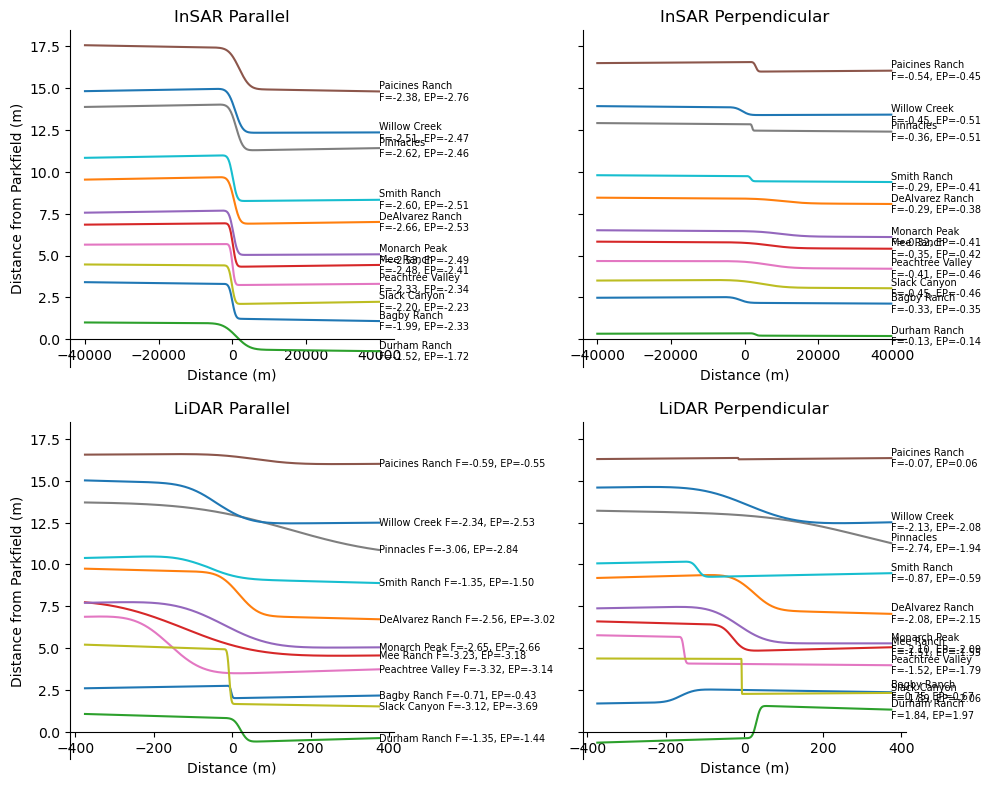

In [11]:
from matplotlib.patches import Rectangle, ConnectionPatch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt

def repel_labels(y_positions, min_sep=0.15):
    """
    Simple 1D vertical repulsion.
    Ensures labels are at least min_sep apart.
    """
    y_sorted_idx = np.argsort(y_positions)
    y_sorted = np.array(y_positions)[y_sorted_idx]

    for i in range(1, len(y_sorted)):
        if y_sorted[i] - y_sorted[i-1] < min_sep:
            y_sorted[i] = y_sorted[i-1] + min_sep

    # return to original order
    y_out = np.zeros_like(y_sorted)
    y_out[y_sorted_idx] = y_sorted
    return y_out

points = center_points
points.fault_azimuth = [-41]*len(points)

ns = sarN
ew = sarE
ud = sarU

lidar_ns = lidN
lidar_ew = lidE

plot = True

# =========================================================
# INSAR COMMON GRID ONLY
# =========================================================
d_common = np.linspace(-profile_length/2, profile_length/2, 400)

norm = mcolors.Normalize(
    vmin=aartk['dist_from_parkfield_m'].min(),
    vmax=aartk['dist_from_parkfield_m'].max()
)
cmap = cm.viridis

show_points = False

insar_par_profiles = []
insar_perp_profiles = []
lidar_par_profiles = []
lidar_perp_profiles = []
labels = []

scale = 7500

for i in np.arange(0, len(points)):

    # =====================================================
    # SAMPLE DATA (UNCHANGED)
    # =====================================================
    ns_samps, pts, dists_s = tt.sample_swath(
        ns, points.geometry.x.iloc[i], points.geometry.y.iloc[i],
        points.fault_azimuth.iloc[i],
        profile_length, profile_width, pixel_res, crs=crs)
    ns_samps[ns_samps == -9999] = np.nan

    ew_samps, _, _ = tt.sample_swath(
        ew, points.geometry.x.iloc[i], points.geometry.y.iloc[i],
        points.fault_azimuth.iloc[i],
        profile_length, profile_width, pixel_res, crs=crs)
    ew_samps[ew_samps == -9999] = np.nan

    ud_samps, _, _ = tt.sample_swath(
        ud, points.geometry.x.iloc[i], points.geometry.y.iloc[i],
        points.fault_azimuth.iloc[i],
        profile_length, profile_width, pixel_res, crs=crs)
    ud_samps[ud_samps == -9999] = np.nan

    par, perp = tt.projectParPerp(
        ns_samps - np.nanmean(ns_samps),
        ew_samps - np.nanmean(ew_samps),
        points.fault_azimuth.iloc[i]
    )

    # =====================================================
    # INSAR FITS
    # =====================================================
    par_fit = tt.erf_curve_fit_twoslope(par, dists_s)
    perp_fit = tt.erf_curve_fit_twoslope(perp, dists_s)

    par_intercept, par_total_offset, par_fault_loc, par_shear_width, \
    par_total_offset_sig, par_fault_loc_sig, par_shear_width_sig, \
    par_slope1, par_slope1_sig, par_slope2, par_slope2_sig, \
    par_fzw_offset, par_ep_offset, intercept_sigma = par_fit

    perp_intercept, perp_total_offset, perp_fault_loc, perp_shear_width, \
    perp_total_offset_sig, perp_fault_loc_sig, perp_shear_width_sig, \
    perp_slope1, perp_slope1_sig, perp_slope2, perp_slope2_sig, \
    perp_fzw_offset, perp_ep_offset, intercept_sigma = perp_fit

    # =====================================================
    # LIDAR + RTK FITS
    # =====================================================
    lidar_ns_samps, _,  dists_l = tt.sample_swath(
        lidar_ns, points.geometry.x.iloc[i], points.geometry.y.iloc[i],
        points.fault_azimuth.iloc[i],
        lid_profile_length, lid_profile_width, lid_pixel_res, crs=crs)

    lidar_ew_samps, _, _= tt.sample_swath(
        lidar_ew, points.geometry.x.iloc[i], points.geometry.y.iloc[i],
        points.fault_azimuth.iloc[i],
        lid_profile_length, lid_profile_width, lid_pixel_res, crs=crs)

    lidar_par, lidar_perp = tt.projectParPerp(
        lidar_ns_samps - np.nanmean(lidar_ns_samps),
        lidar_ew_samps - np.nanmean(lidar_ew_samps),
        points.fault_azimuth.iloc[i]
    )

    lidar_par_fit = tt.erf_curve_fit_twoslope(lidar_par, dists_l)
    lidar_perp_fit = tt.erf_curve_fit_twoslope(lidar_perp, dists_l)

    lidar_par_intercept, lidar_par_total_offset, lidar_par_fault_loc, lidar_par_shear_width, \
    lidar_par_total_offset_sig, lidar_par_fault_loc_sig, lidar_par_shear_width_sig, \
    lidar_par_slope1, lidar_par_slope1_sig, lidar_par_slope2, lidar_par_slope2_sig, \
    lidar_par_fzw_offset, lidar_par_ep_offset, lidar_intercept_sigma = lidar_par_fit

    lidar_perp_intercept, lidar_perp_total_offset, lidar_perp_fault_loc, lidar_perp_shear_width, \
    lidar_perp_total_offset_sig, lidar_perp_fault_loc_sig, lidar_perp_shear_width_sig, \
    lidar_perp_slope1, lidar_perp_slope1_sig, lidar_perp_slope2, lidar_perp_slope2_sig, \
    lidar_perp_fzw_offset, lidar_perp_ep_offset, lidar_intercept_sigma = lidar_perp_fit

    # --- your existing fitting happens here ---
    df = aartk[aartk.Name == points.iloc[i].Name]
    dist_pf = df['dist_from_parkfield_m'].mean()

    # ------------------------
    # INSAR MODELS
    # ------------------------
    insar_par_model = tt.erf_function_twoslope(
        dists,
        par_intercept, par_total_offset,
        par_fault_loc, par_shear_width,
        par_slope1, par_slope2
    )

    insar_perp_model = tt.erf_function_twoslope(
        dists,
        perp_intercept, perp_total_offset,
        perp_fault_loc, perp_shear_width,
        perp_slope1, perp_slope2
    )

    insar_par_profiles.append(
        (dists.copy(), insar_par_model.copy(), dist_pf,
         par_fzw_offset, par_ep_offset)
    )

    insar_perp_profiles.append(
        (dists.copy(), insar_perp_model.copy(), dist_pf,
         perp_fzw_offset, perp_ep_offset)
    )

    # ------------------------
    # LIDAR MODELS
    # ------------------------
    if len(dists_l) > 0:

        lidar_par_model = tt.erf_function_twoslope(
            dists_l,
            lidar_par_intercept, lidar_par_total_offset,
            lidar_par_fault_loc, lidar_par_shear_width,
            lidar_par_slope1, lidar_par_slope2
        )

        lidar_perp_model = tt.erf_function_twoslope(
            dists_l,
            lidar_perp_intercept, lidar_perp_total_offset,
            lidar_perp_fault_loc, lidar_perp_shear_width,
            lidar_perp_slope1, lidar_perp_slope2
        )

        lidar_par_profiles.append(
            (dists_l.copy(), lidar_par_model.copy(), dist_pf,
             lidar_par_fzw_offset, lidar_par_ep_offset)
        )

        lidar_perp_profiles.append(
            (dists_l.copy(), lidar_perp_model.copy(), dist_pf,
             lidar_perp_fzw_offset, lidar_perp_ep_offset)
        )

    labels.append(points.Name.iloc[i])

# ============================================
# PLOTTING (UPDATED TEXT)
# ============================================
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharey=True)

def style_axis(ax, title):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_position(('data', 0))
    ax.spines['left'].set_position(('axes', 0))
    ax.set_title(title)
    ax.set_xlabel('Distance (m)')
    ax.grid(False)

# ------------------------
# INSAR PARALLEL
# ------------------------
ax = axs[0,0]
ys = []
for (d, f, y, fzw, ep) in insar_par_profiles:
    y0 = y / scale
    ys.append(f[-1] + y0)

ys_rep = repel_labels(ys)

for (d, f, y, fzw, ep), label, y_lab in zip(insar_par_profiles, labels, ys_rep):
    y0 = y / scale
    ax.plot(d, f + y0, lw=1.5)

    ax.text(
        d[-1],
        y_lab,
        f"{label}\nF={fzw:.2f}, EP={ep:.2f}",
        fontsize=7,
        va='center'
    )

style_axis(ax, 'InSAR Parallel')
ax.set_ylabel('Distance from Parkfield (m)')

# ------------------------
# INSAR PERP
# ------------------------
ax = axs[0,1]
ys = []
for (d, f, y, fzw, ep) in insar_perp_profiles:
    y0 = y / scale
    ys.append(f[-1] + y0)

ys_rep = repel_labels(ys)

for (d, f, y, fzw, ep), label, y_lab in zip(insar_perp_profiles, labels, ys_rep):
    y0 = y / scale
    ax.plot(d, f + y0, lw=1.5)

    ax.text(
        d[-1],
        y_lab,
        f"{label}\nF={fzw:.2f}, EP={ep:.2f}",
        fontsize=7,
        va='center'
    )

style_axis(ax, 'InSAR Perpendicular')

# ------------------------
# LIDAR PARALLEL
# ------------------------
ax = axs[1,0]
ys = []
for (d, f, y, fzw, ep) in lidar_par_profiles:
    y0 = y / scale
    ys.append(f[-1] + y0)

ys_rep = repel_labels(ys)

for (d, f, y, fzw, ep), label, y_lab in zip(lidar_par_profiles, labels, ys_rep):
    y0 = y / scale
    ax.plot(d, f + y0, lw=1.5)

    ax.text(
        d[-1],
        y_lab,
        f"{label} F={fzw:.2f}, EP={ep:.2f}",
        fontsize=7,
        va='center'
    )

style_axis(ax, 'LiDAR Parallel')
ax.set_ylabel('Distance from Parkfield (m)')

# ------------------------
# LIDAR PERP
# ------------------------
ax = axs[1,1]
ys = []
for (d, f, y, fzw, ep) in lidar_perp_profiles:
    y0 = y / scale
    ys.append(f[-1] + y0)

ys_rep = repel_labels(ys)

for (d, f, y, fzw, ep), label, y_lab in zip(lidar_perp_profiles, labels, ys_rep):
    y0 = y / scale
    ax.plot(d, f + y0, lw=1.5)

    ax.text(
        d[-1],
        y_lab,
        f"{label}\nF={fzw:.2f}, EP={ep:.2f}",
        fontsize=7,
        va='center'
    )

style_axis(ax, 'LiDAR Perpendicular')

plt.tight_layout()
plt.show()



NameError: name 'bh80' is not defined

Endpoint diff: 1.9399999999196789
Fault Center Diff:
Max diff: 2.1475806692681276
Shear width diff: 1.9089994722072832


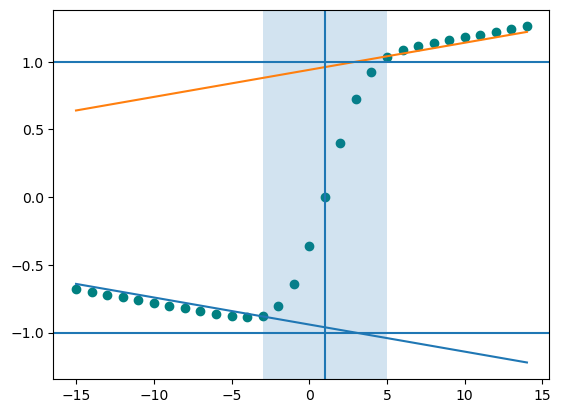

In [ ]:
x = np.arange(-15,15)
offset = 2
width = 2
center, intercept = 1, 0
m1 = -offset/100
m2 = offset/100
y1 = tt.erf_function_twoslope(x, intercept, offset, center, width, m1, m2) # a b c ws m1 m2
y2 = tt.fit_arctan_independent_slopes(x, offset/3, width/3, center, m1, m2, intercept) # b ws c m1 m2 a
plt.scatter(x,y1,color='teal')
plt.plot(x,m1*(x-center-width)-offset/2)
plt.plot(x,m2*(x-center-width)+offset/2)
#plt.scatter(x,y2,color='black')
plt.axhline(-1*offset/2)
plt.axhline(offset/2)
plt.axvspan(center-width*2,center+width*2,alpha=0.2)
plt.axvline(center)
print('Endpoint diff:', y1[-1]-y1[0])
print('Fault Center Diff:',)
print('Max diff:',y1.max()-y1.min())
print('Shear width diff:',tt.erf_function_twoslope(center+width*2, intercept, offset, center, width, m1, m2) - tt.erf_function_twoslope(center-width*2, intercept, offset, center, width, m1, m2))

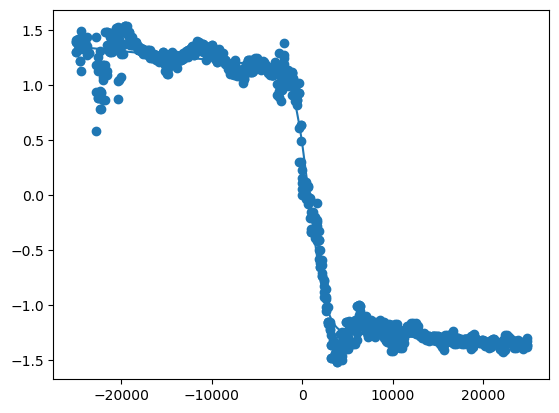

In [ ]:
mult = (np.nanmax(par)-np.nanmin(par))/1000
# a, b, c, ws, m1, m2
bounds = ((-np.inf,np.nanmin(par)*2,dists.min(),0,-1*mult,-1*mult),(np.inf,np.nanmax(par)*2,dists.max(),dists.max(),1*mult,1*mult))
max_diff = np.nanmax(par)-np.nanmin(par)
bounds = ((-np.inf,-max_diff*2,dists.min(),0,-max_diff/np.nanmax(dists),-max_diff/np.nanmax(dists)),(np.inf,max_diff*2,dists.max(),dists.max(),max_diff/np.nanmax(dists),max_diff/np.nanmax(dists)))
par_intercept, par_total_offset, par_fault_loc, par_shear_width, par_total_offset_sig, par_fault_loc_sig, par_shear_width_sig, slope1, slope1_sig, slope2, slope_2sig = tt.erf_curve_fit_twoslope(par, dists, bounds=None)
plt.plot(dists,tt.erf_function_twoslope(dists,par_intercept,par_total_offset, par_fault_loc, par_shear_width,slope1,slope2))
plt.scatter(dists,par)

In [ ]:
mult

np.float64(0.03053988739955471)

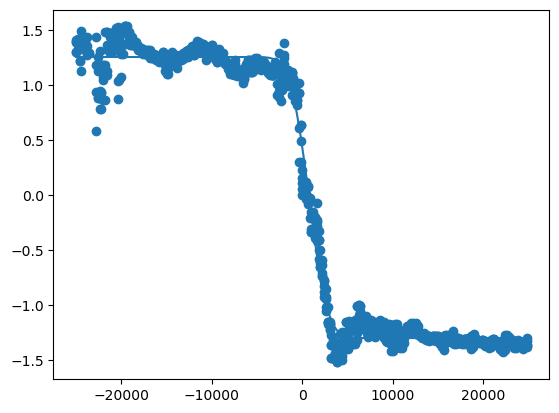

In [ ]:
mult = 0
# a, b, c, ws, m1, m2
bounds = ((-np.inf,np.nanmin(par)*2,dists.min(),0),(np.inf,np.nanmax(par)*2,dists.max(),dists.max()))
par_intercept, par_total_offset, par_fault_loc, par_shear_width, par_total_offset_sig, par_fault_loc_sig, par_shear_width_sig = tt.erf_curve_fit_noslope(par, dists, bounds=None)
plt.plot(dists,tt.erf_function_noslope(dists,par_intercept,par_total_offset, par_fault_loc, par_shear_width))
plt.scatter(dists,par)